# Validation Duck

## Paths & Co

In [1]:
new_kalman_run = True
animation = True
covMatrix = 'diagonal'

In [2]:
# path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_tc = path_to_data_folder + '01_tides/output/'
path_validation = path_to_data_folder + '02_Duck_validation_data/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '22_23_Duck_DEM/input/'
path_output = path_to_data_folder + '22_23_Duck_DEM/output/'
path_altimetry_output = path_to_data_folder + '21_Duck_altimetry/output/'
path_transect_polys = path_to_data_folder + '06_Duck_transect_polys/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n36.6257_s35.7784_w-76.1201_e-75.3896.nc'
fn_ddtm = 'DeltaDTM_v1_0_N36W076.tif'

epsg = 4326 # WGS84
epsg_local = 32618

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1 # filter length from one epoch to the next

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_visualisation
import P2_functions

In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [5]:
# Observational noise
sigma_l = 0.35

# Model noise
factor = 10
sigma_q = factor * sigma_l

# Standard deviation of the initial state
std_init = 3

print(f'Observational noise: {round(sigma_l,2)} m')
print(f'Model noise: {round(sigma_q,2)} m')
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.35 m
Model noise: 3.5 m
Standard deviation of the initial state: 3 m


In [6]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Sea level

In [7]:
# Altimetry
fn = 'tp_plus_ales_epsg32618.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [8]:
# Correct altimetry for dynamic atmospheric correction (DAC)
dac = xr.open_dataset(path_input + 'dac_duck.nc')
dac_interp = np.interp(alt.index, pd.to_datetime(dac.time.values), dac.dac.values)

alt_corr_dac = alt.sla + dac_interp

In [9]:
# Tide gauge
path = path_to_data_folder + '01_tides/input/'
fn = 'TG_Duck_hourly.csv'
tg = pd.read_csv(path + fn, header=None, names=['year','month','day','hour','sealevel'])
# Set datetime index together
tg['datetime'] = pd.to_datetime({'year': tg['year'], 'month': tg['month'], 'day': tg['day'], 'hour': tg['hour']})
tg = tg.set_index('datetime').sort_index()
tg.sealevel = tg.sealevel/1000 # convert from mm to m
tg.loc[tg.sealevel < -10, 'sealevel'] = np.nan

tg.sealevel = tg.sealevel - 6.20
tg_monthly_av = tg.groupby(pd.Grouper(freq='ME')).mean()
tg_monthly_av.index = tg_monthly_av.index.tz_localize("UTC")

subtract 6.20 m to get to MSL  
https://uhslc.soest.hawaii.edu/stations/TIDES_DATUMS/fd/LST/fd260/d260_m.png

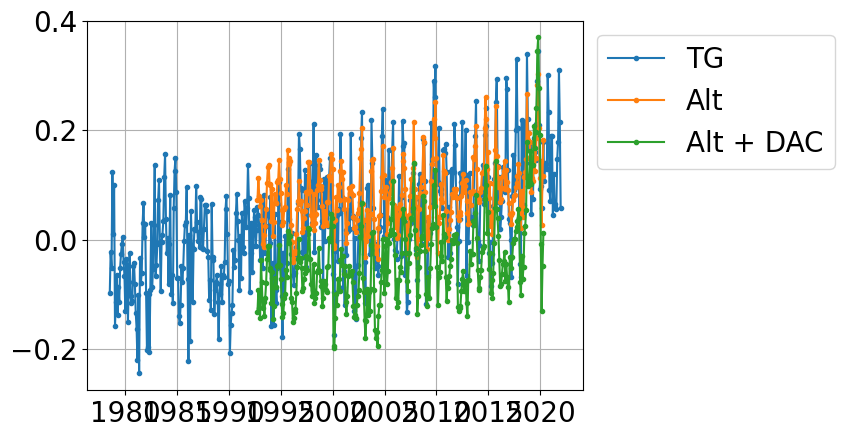

In [10]:
plt.plot(tg_monthly_av.index, tg_monthly_av.sealevel, '.-', label='TG')
plt.plot(alt.index, alt.sla, '.-', label='Alt')
plt.plot(alt_corr_dac.index,alt_corr_dac, '.-', label='Alt + DAC')

plt.legend(bbox_to_anchor=(1,1))
plt.grid()

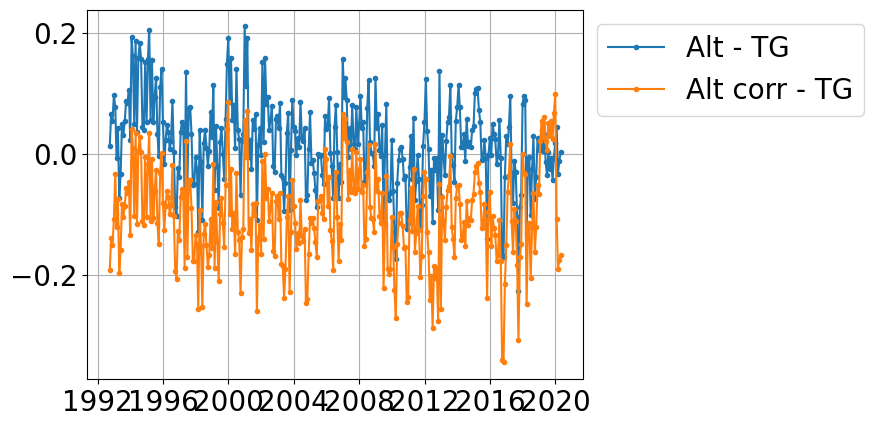

In [11]:
diff_alt_tg = alt.sla - tg_monthly_av.sealevel
plt.plot(diff_alt_tg.index, diff_alt_tg, '.-', label='Alt - TG')

diff_altcorr_tg = alt_corr_dac - tg_monthly_av.sealevel
plt.plot(diff_altcorr_tg.index, diff_altcorr_tg, '.-', label='Alt corr - TG')

plt.legend(bbox_to_anchor=(1,1))
plt.grid()

In [12]:
# Tidal correction
fn = 'tides_duck.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

### Shorelines

In [13]:
# Cassie shorelines
folders = ['1_1992-08-10_1995-02-24/',
          '2_1995-03-21_2001-03-12/',
          '3_2001-04-13_2009-03-18/',
          '4_2009-04-12_2018-02-07/',
          '5_2018-02-23_2025-03-06/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt_corr_dac.index[0]) & (np.array(sl_cassie['dates']) <= alt_corr_dac.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

292 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 90 points (min: 55, max: 215).


In [14]:
# number of shorelines per year
num_imgs = pd.DataFrame([_.year for _ in c_dates]).value_counts(sort=False)
num_imgs = num_imgs.reset_index(level=[0])
num_imgs.to_pickle(path_output+'num_imgs_Duck.pkl')

In [15]:
# Load outlier-corrected shorelines
c_shorelines_corr = pickle.load(open(path_output + 'c_shorelines_corr.pkl', 'rb'))
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

### Validation data

In [16]:
duck_vali = xr.open_dataset(path_validation+'duck_validation.nc')

# Reduce to time period
vali_years = pd.to_datetime(duck_vali.time).year
idx_time, = np.where((vali_years >= year_start) & (vali_years <= year_end))
duck_vali = duck_vali.isel(time=idx_time)

# xarray DataSet to GeoDataFrame
lon_vali = duck_vali.longitude.values.reshape(-1)
lat_vali = duck_vali.latitude.values.reshape(-1)

elev_vali = duck_vali['elevation'].values.reshape(len(duck_vali.time), len(duck_vali.xFRF)*len(duck_vali.yFRF))

dates = pd.to_datetime(duck_vali.time)
vali_df = pd.DataFrame(elev_vali, index=dates)

# yearly means anchored in June
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
valid_df_yearly = vali_df.groupby(pd.Grouper(freq='YE-JUN')).mean()
valid_df_yearly.index = valid_df_yearly.index.year

vali_gdf = gpd.GeoDataFrame(valid_df_yearly.T, geometry=gpd.points_from_xy(lon_vali, lat_vali))
vali_gdf = vali_gdf.set_crs('4326')
vali_gdf.columns = [str(_) for _ in vali_gdf.columns]

vali_gdf = vali_gdf.drop(columns=['2012', '2021'], errors='ignore')

### Transect polygons

In [17]:
transect_polys = pickle.load(open(path_transect_polys + 'transect_polys.pkl', 'rb'))

### Initial state

In [18]:
init = xr.open_dataset(path_output+'init_4326_resolution_50m.tif').squeeze()
poly_sl_corr = pickle.load(open(path_output + f'poly_sl_corr{epsg}.pkl', 'rb'))

## Generate RTS-DTM

In [19]:
fn = 'x_state_s_readd.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    year_ref = 2006
    n_iter = 2

    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Initialise state vector
    init_df = init.to_dataframe().dropna()
    x = init_df.index.get_level_values('x')
    y = init_df.index.get_level_values('y')    
    x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
    x_state = x_state.set_crs(epsg)

    if covMatrix == 'diagonal':
        sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
        sigma_xx_init = diags_array(sigma_xx_init_df.sigma)
    elif covMatrix == 'full':
         sigma_xx_init = CD_kalman.build_covMatrix(x_state, std_init, epsg_local, n_neighbours=10) 

    # "Iteration 0"
    x_k = x_state['init'].copy()
    sigma_xx_k = sigma_xx_init

    # Initial trend 
    trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)
    # trends = gpd.GeoDataFrame(columns=['trend_k']) # no trend removal

    for i in range(0, n_iter):
        x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
              x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
              seg_length, alt_corr_dac, tidal_corr, epsg, epsg_local, T_is_identity, max_distance, w_id,
              max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref, covMatrix)

        # New trend
        trends[f'trend_{i}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
        # Overwrite  trend_k for next iteration
        trends['trend_k'] = trends.drop(columns=['geometry', 'trend_k']).cumsum(axis=1).iloc[:,-1].copy()

        # Overwrite x_k so that next iteration starts with residuals and not the full signal
        x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
        sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

    # Re-add trend
    x_state_readd = x_state.copy()
    x_state_s_readd = x_state_s.copy()

    all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
    trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

    year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
    for year in year_list:
        deltaYear = year - year_ref   
        x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
        x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
        x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

    kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state_readd, x_state_s_readd)
    
    # Save kf output
    pickle.dump(x_state_readd, open(f'{path_output}x_state_readd.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s_readd, open(f'{path_output}x_state_s_readd.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save trends
    pickle.dump(all_trends, open(f'{path_output}all_trends.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state_readd.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s_readd.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load trends
    all_trends = pickle.load(open(f'{path_output}all_trends.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")

Forward run done. Needed  14.0 seconds.
Forward run done. Needed  15.2 seconds.
Backward run done. Needed  2.7 seconds.
Interpolation done. Needed  0.3 seconds.


These are elevation trends  
Results are volume trends  

trend_0 is the trend computed after the first run and subtracted in the second run  
trend_1 is the trend computed after the second run 
... should therefore be only the residual estimated by the KF  
Residual is on average larger than the trend after the first run  
but standard deviations become smaller (also clearly visible in the histograms)  
Test with five runs:  
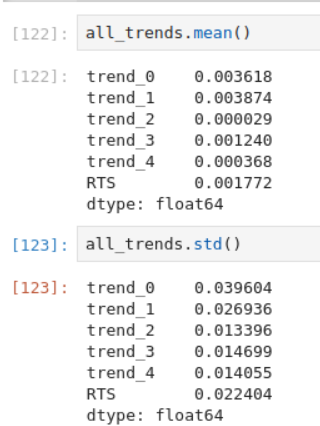

In [48]:
all_trends['RTS'] = CD_kalman.compute_trend_in_each_gridpoint(x_state_s)
all_trends['RTS_readd'] = CD_kalman.compute_trend_in_each_gridpoint(x_state_s_readd)   

In [49]:
all_trends.mean().round(3)

trend_0      0.004
trend_1      0.004
RTS          0.004
RTS_readd    0.009
dtype: float64

In [50]:
all_trends.std().round(3)

trend_0      0.039
trend_1      0.027
RTS          0.019
RTS_readd    0.037
dtype: float64

trend_0: Trend removed after 1st KF run  
trend_1: Residual trend after 2nd KF run  
RTS: Residual trend after 2nd KF and RTS run  
RTS_readd: Restored trend

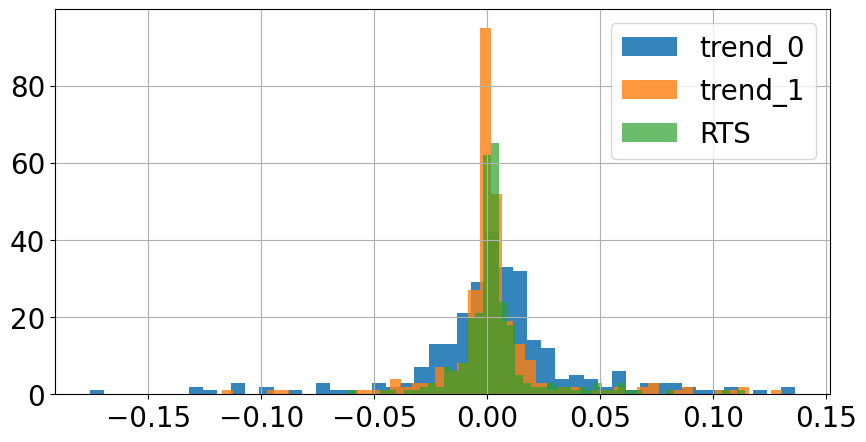

In [24]:
fig, ax = plt.subplots(figsize=(10,5))
alpha = 1
for col in all_trends.columns:
    alpha = alpha-.1
    ax.hist(all_trends[col], bins=50, label=str(col), alpha=alpha)
    ax.legend()
ax.grid()

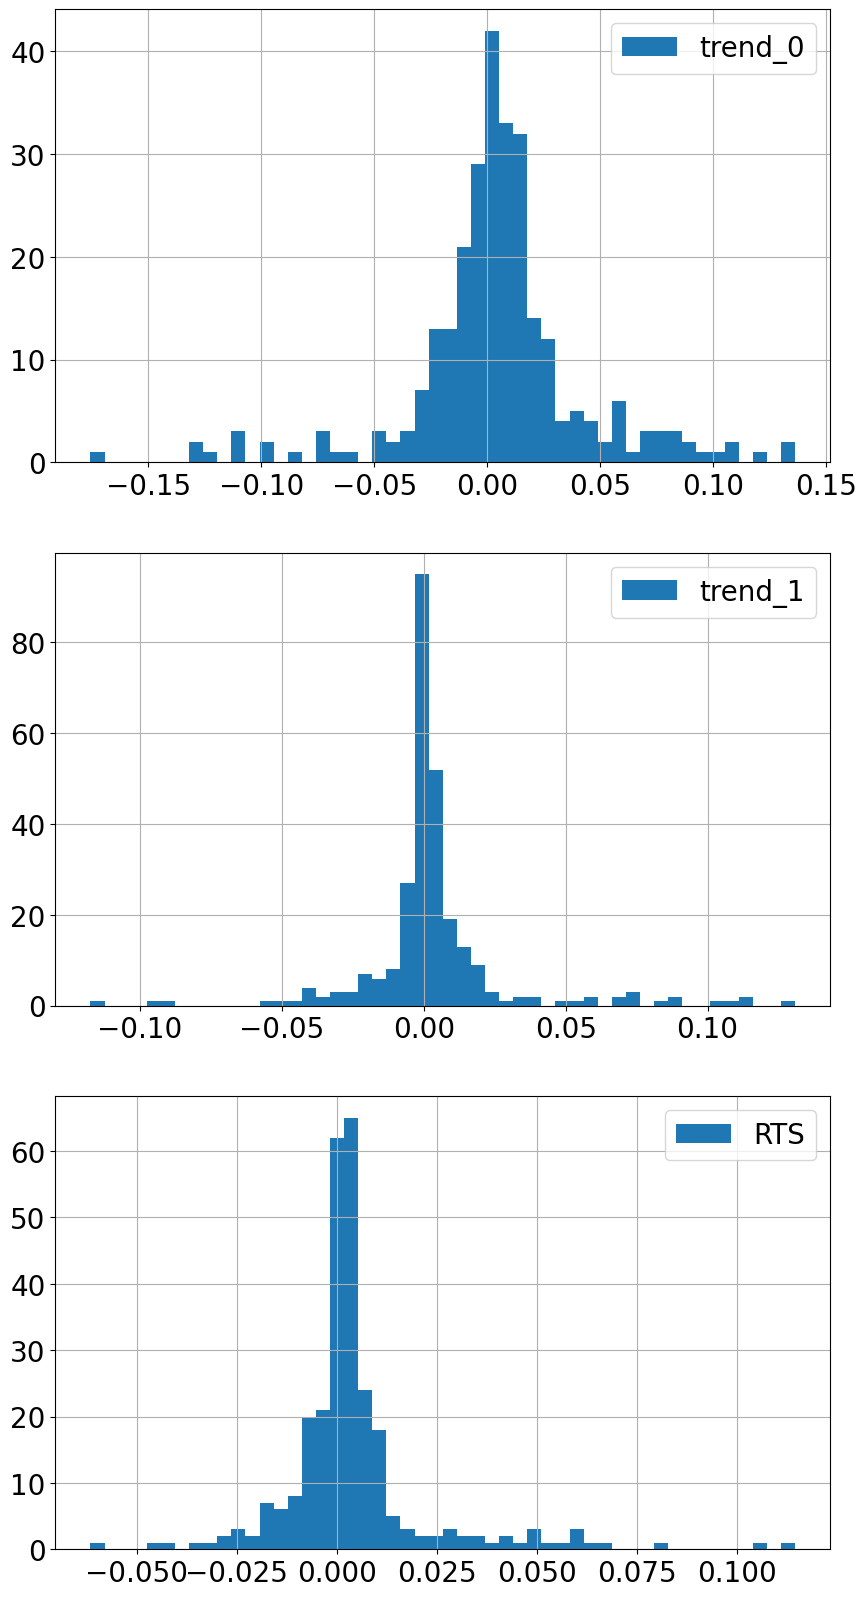

In [25]:
fig, axs = plt.subplots(len(all_trends.columns), figsize=(10,20))
for i, col in enumerate(all_trends.columns):
    axs[i].hist(all_trends[col], bins=50, label=str(col))
    axs[i].legend()
    axs[i].grid()

## Remove height difference between validation and new DTM
from different height reference systems

Reducing the bias somehow produces a larger bias in the volume change curves (does not change elevation statistics), so will not reduce it for now:

In [26]:
vali_red = vali_gdf

## Statistics of elevation differences

In [27]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(vali_red.geometry.x, vali_red.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', vali_red.geometry.x, vali_red.geometry.y)

### Initial state - validation

In [28]:
vali_temp_mean = vali_red.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - vali_temp_mean
print(f'Difference initial state - vali has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - vali has 714 non-NaN values.


In [29]:
CD_statistics.print_stats(diff_init)

Mean error: -1.61 m
---De-bias with mean---
Mean error: 0.0 m
Mean absolute error: 1.68 m
Root mean square error: 2.1 m
Mean absolute deviation from mean: 1.68 m
Median absolute deviation from median: 1.49 m


In [30]:
year_list = [int(_) for _ in vali_red.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], vali_red, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - validation

In [31]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, vali_red, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, vali_red, year_list, reduce_mean=True, static=False)

In [32]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [33]:
def plot_stats(ax, which_stat, title, legend=False):
    ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - validation')
    ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
    ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

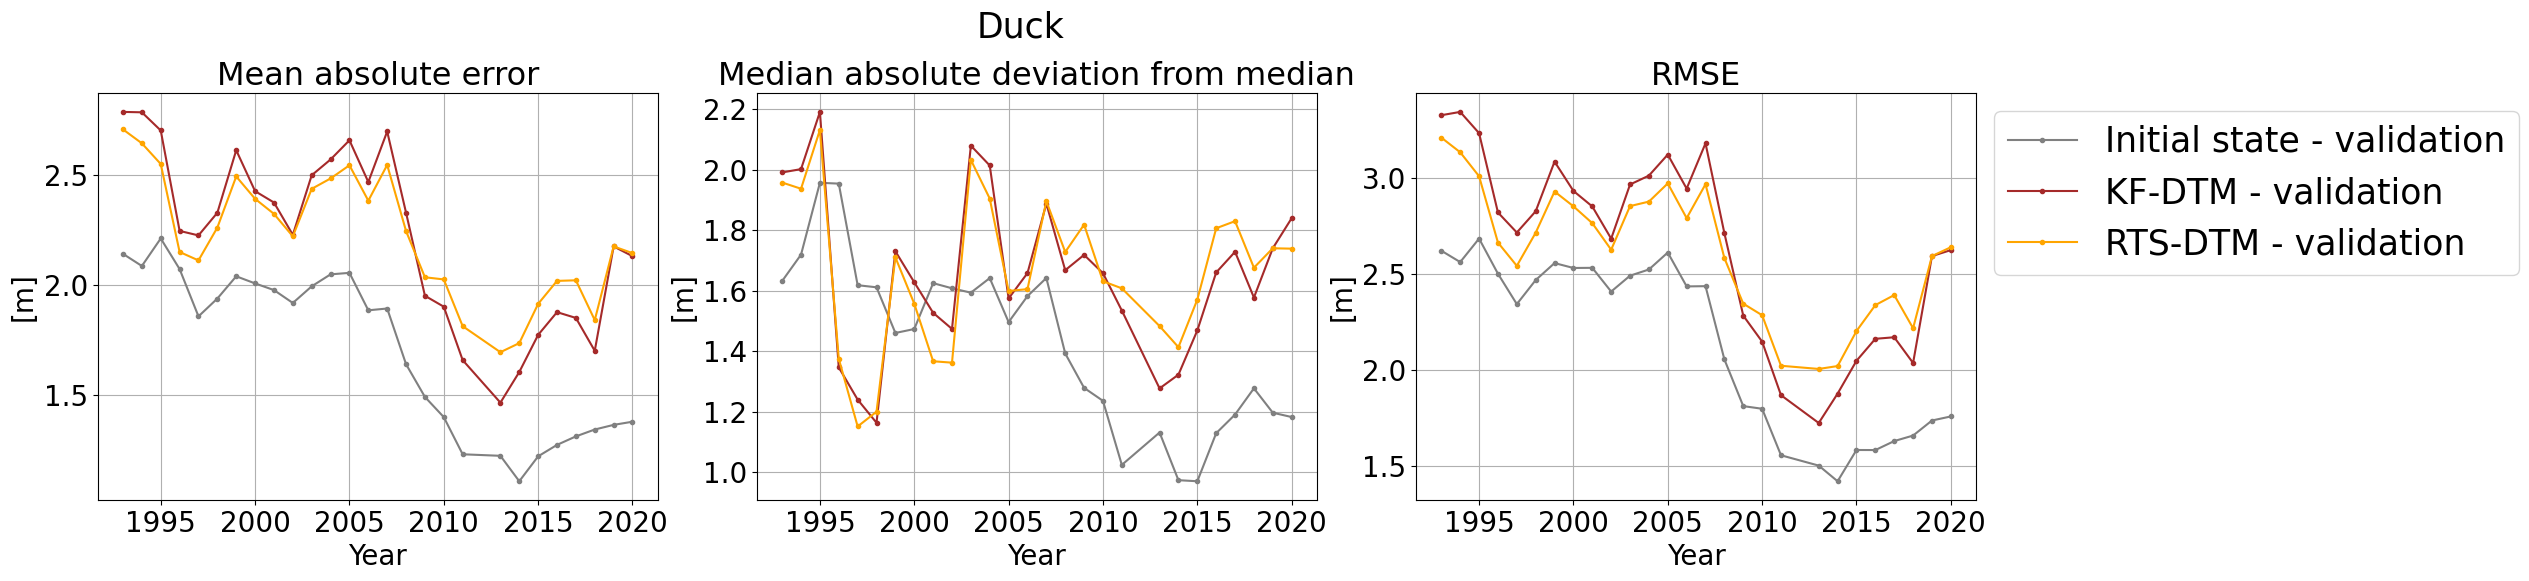

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle(f'Statistics of elevation differences averaged over the area covered by shoreline observations ({len(rts_inside_sl)} points)', y=1.1, fontsize=25)
fig.suptitle('Duck', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Duck_vali_elevation_differences.png', dpi=300, bbox_inches='tight')

#### Quantify difference init - KF/RTS
positive: init has (on average) larger error  
negative: KF/RTS has larger error  

In [35]:
print(f'Average difference init-KF (inside shoreline area):')
print(f'ME: {round((stats_gdf_init.mae - stats_gdf_kf.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init.mad_med - stats_gdf_kf.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init.rmse - stats_gdf_kf.rmse).mean(),2)} m')

print(f'\nAverage difference init-RTS (inside shoreline area):')
print(f'ME: {round((stats_gdf_init.mae - stats_gdf_rts.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init.mad_med - stats_gdf_rts.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init.rmse - stats_gdf_rts.rmse).mean(),2)} m')

Average difference init-KF (inside shoreline area):
ME: -0.52 m
MAD: -0.23 m
RMSE: -0.5 m

Average difference init-RTS (inside shoreline area):
ME: -0.51 m
MAD: -0.23 m
RMSE: -0.47 m


### Maps

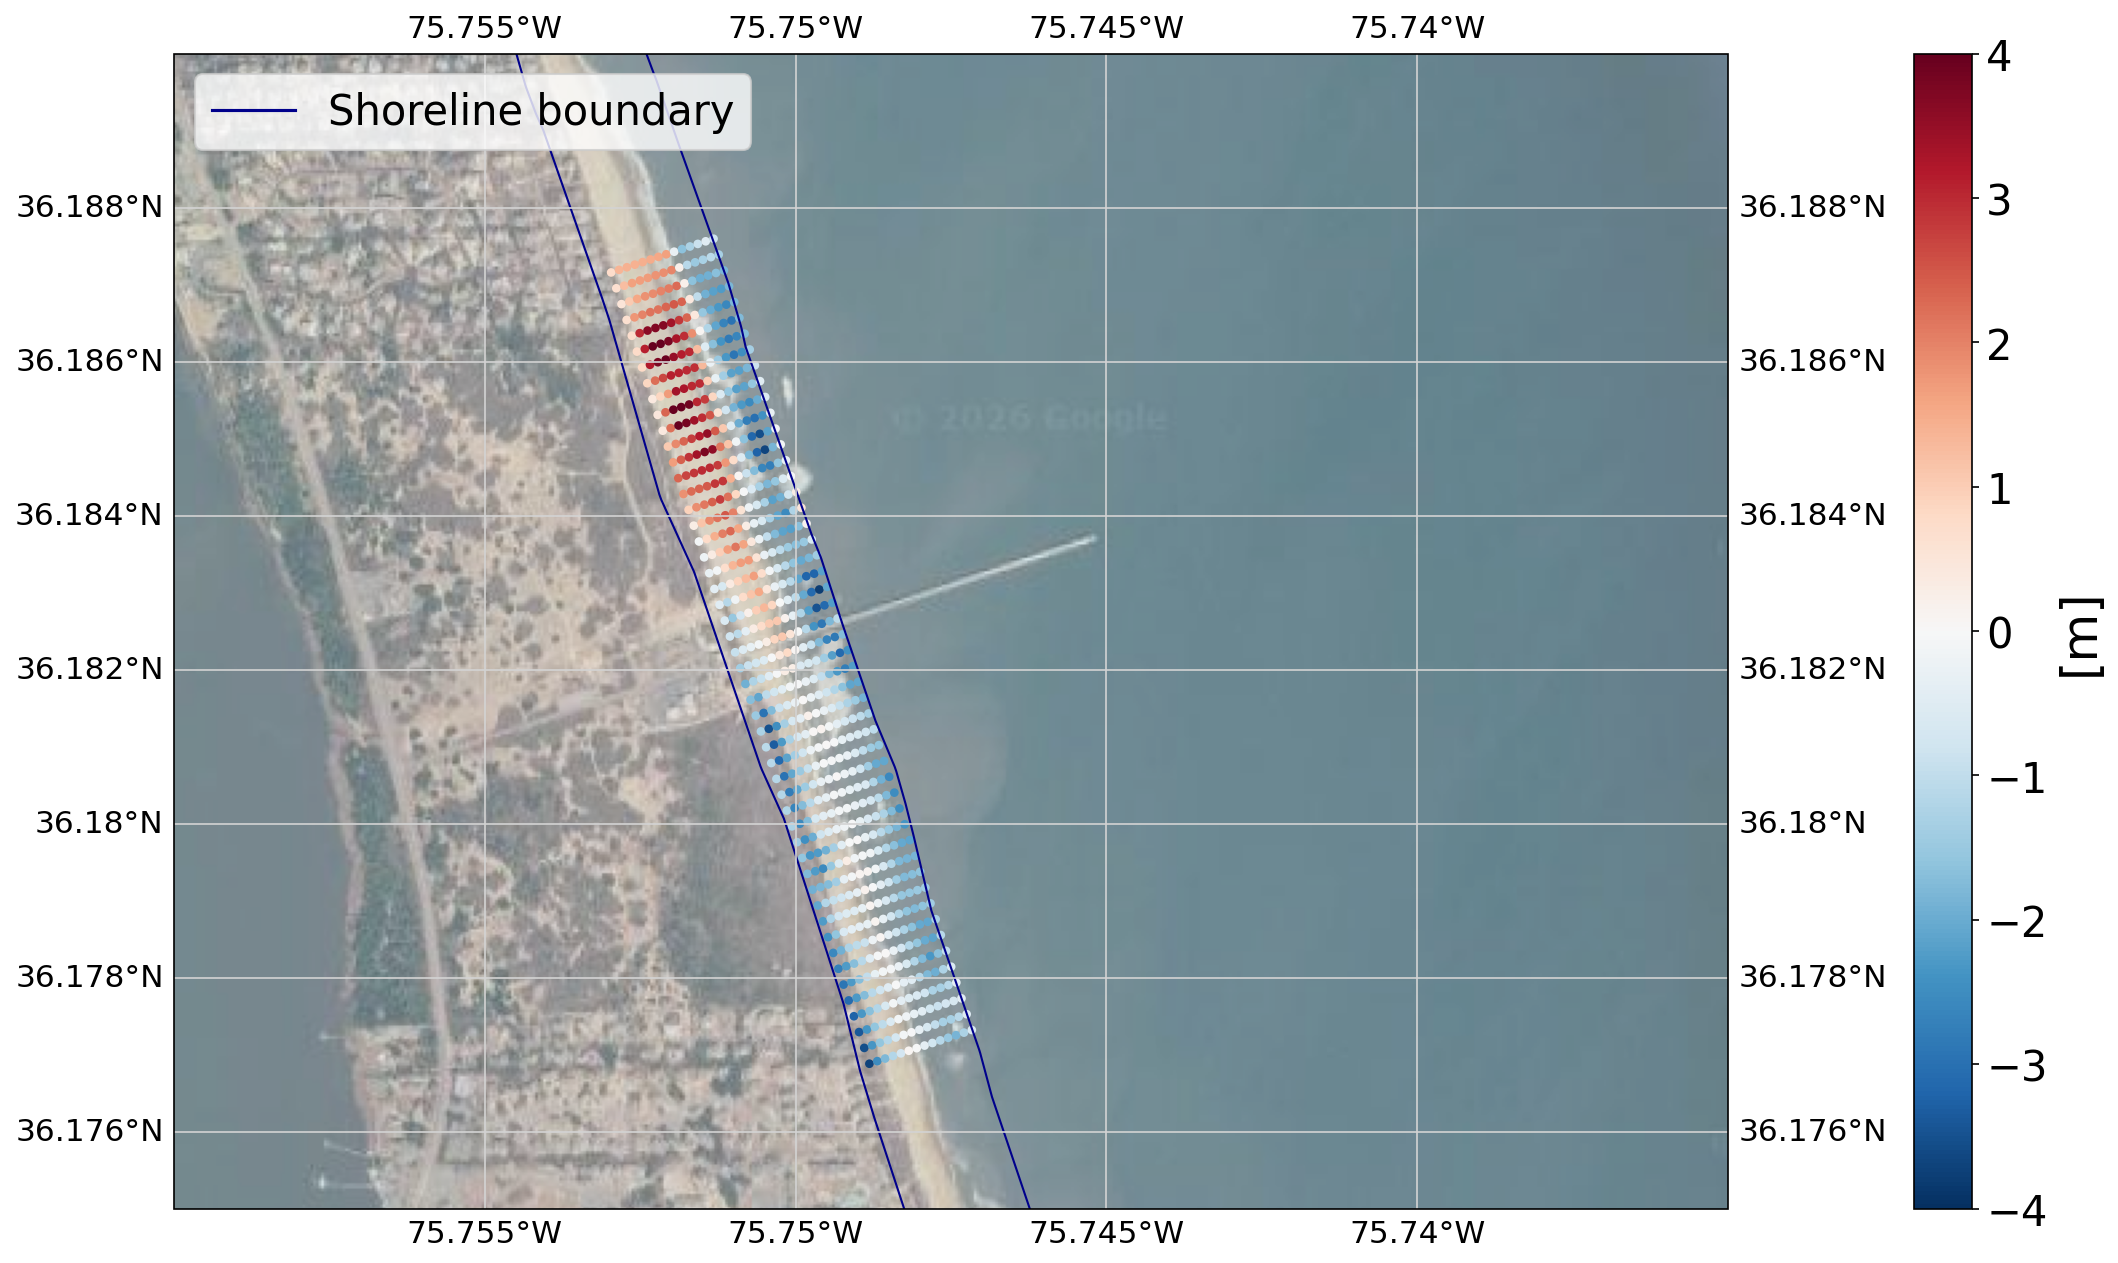

In [47]:
year = '1993'
diff_init = init_interp['init'] - vali_red[year]
diff_rts = rts_interp[year] - vali_red[year]
diff_rts_init = np.abs(diff_init) - np.abs(diff_rts)

extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

x = vali_red.geometry.x
y = vali_red.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff_rts_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

# ax.add_geometries(poly_target_red, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
# ax.set_title(f'Difference of errors initial state - RTS-DTM {year} for Duck', fontsize=24);

plt.savefig(f'{path_output}Duck_map_diff_errors_init-RTS_{year}.png', dpi=300, bbox_inches='tight')

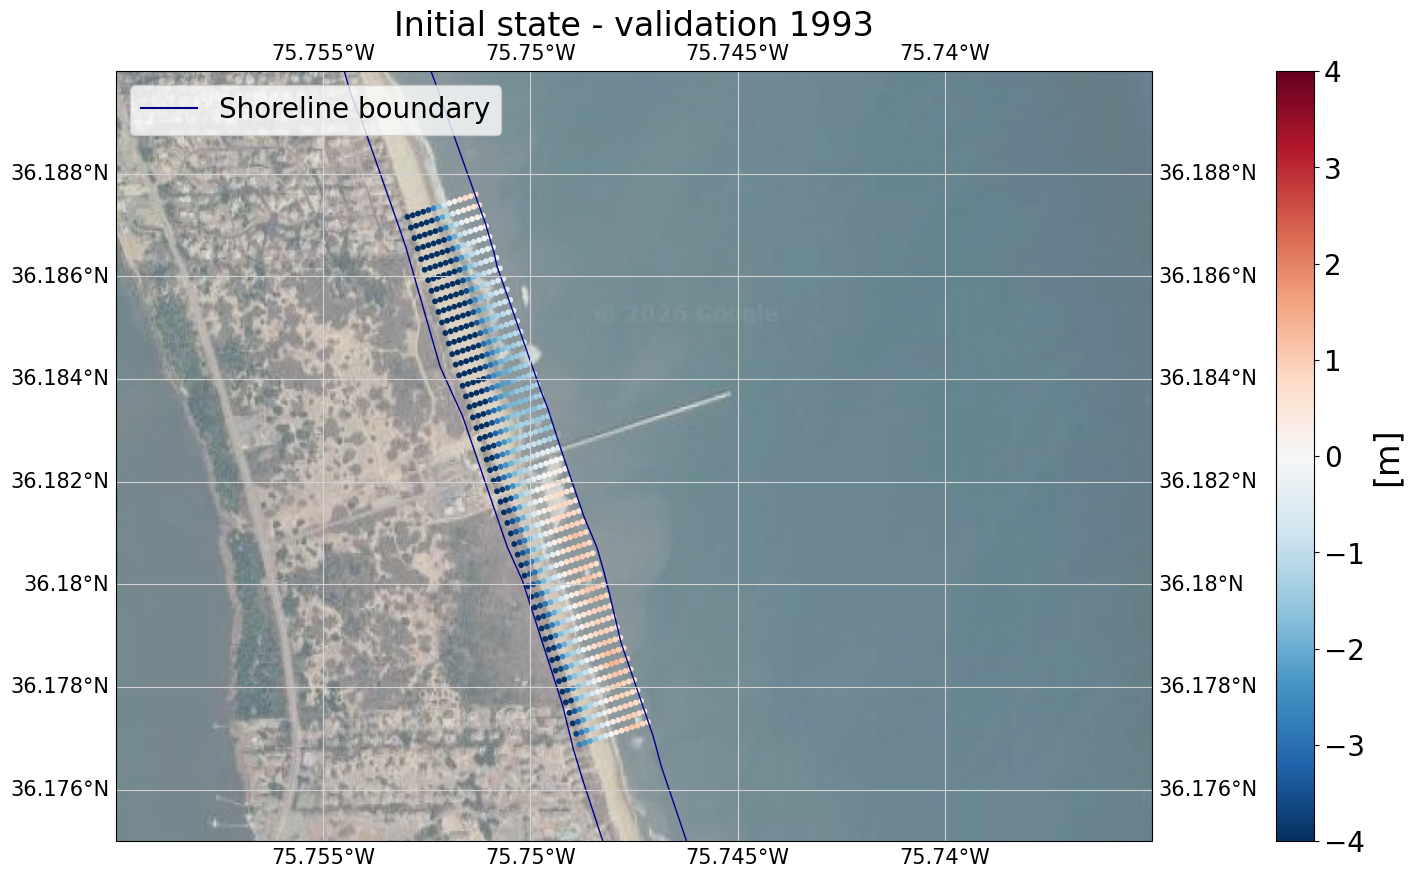

In [37]:
extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(x, y, marker='o', s=10, c=diff_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'Initial state - validation 1993', fontsize=24);

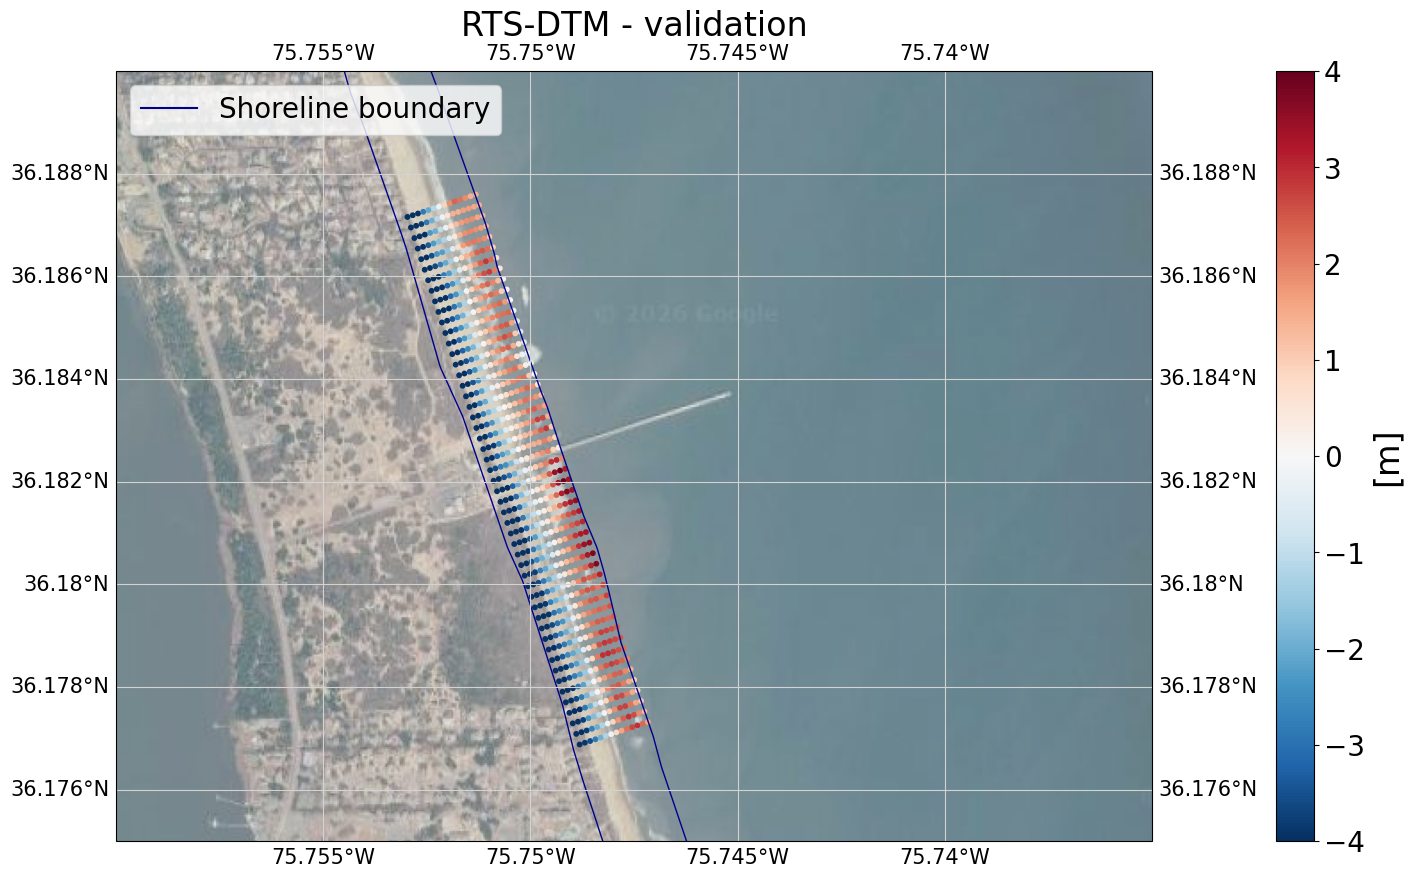

In [38]:
extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(x, y, marker='o', s=10, c=diff_rts, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'RTS-DTM - validation', fontsize=24);

## Volume changes

In [39]:
volumes_vali, volumes_kf, volumes_rts = P2_functions.get_all_volumes(vali_red, kf_interp, rts_interp, transect_polys, epsg_local)

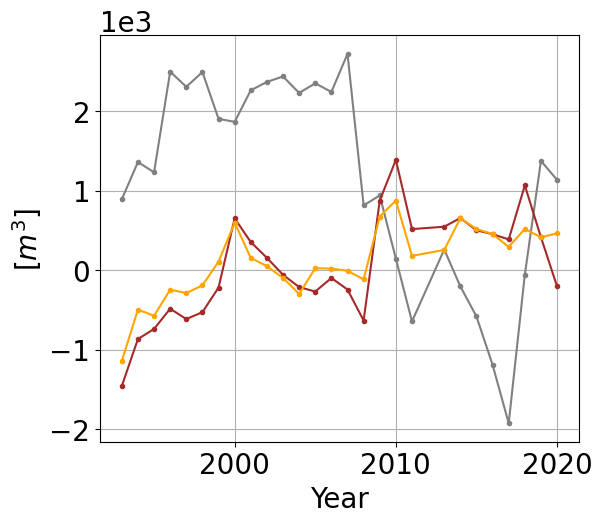

In [40]:
fig, ax = plt.subplots(figsize=(6,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.25)

ax.plot(volumes_vali.index, volumes_vali.mean(axis=1), '.-', c=c_init, label='Validation')
ax.plot(volumes_kf.index, volumes_kf.mean(axis=1), '.-', c=c_kf, label='KF-DTM')
ax.plot(volumes_rts.index, volumes_rts.mean(axis=1), '.-', c=c_rts, label='RTS-DTM')
ax.set_ylabel(r'[$m^3$]')
ax.set_xlabel('Year')
# ax.legend(bbox_to_anchor=(1,1), fontsize=22)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid()
# fig.suptitle('Volume changes Duck', fontsize=25, y=1.1)
plt.savefig(f'{path_output}Duck_validation_volume_changes.png', dpi=300, bbox_inches='tight')

### Statistics compared to the validation data set

In [41]:
trends, trend_diff_perc, corr, pvalues, rmse, rmse_perc = P2_functions.volume_stats_averaged(volumes_vali, volumes_kf, volumes_rts, print_output=True)
pickle.dump(trends, open(path_output+'Duck_validation_trends.pkl', 'wb'))

Trend differences in % of total trend: -140.9
RMSE relative to total mean volume: 130.0
Correlation:-0.42, p: 0.03


## Animation

#### KF

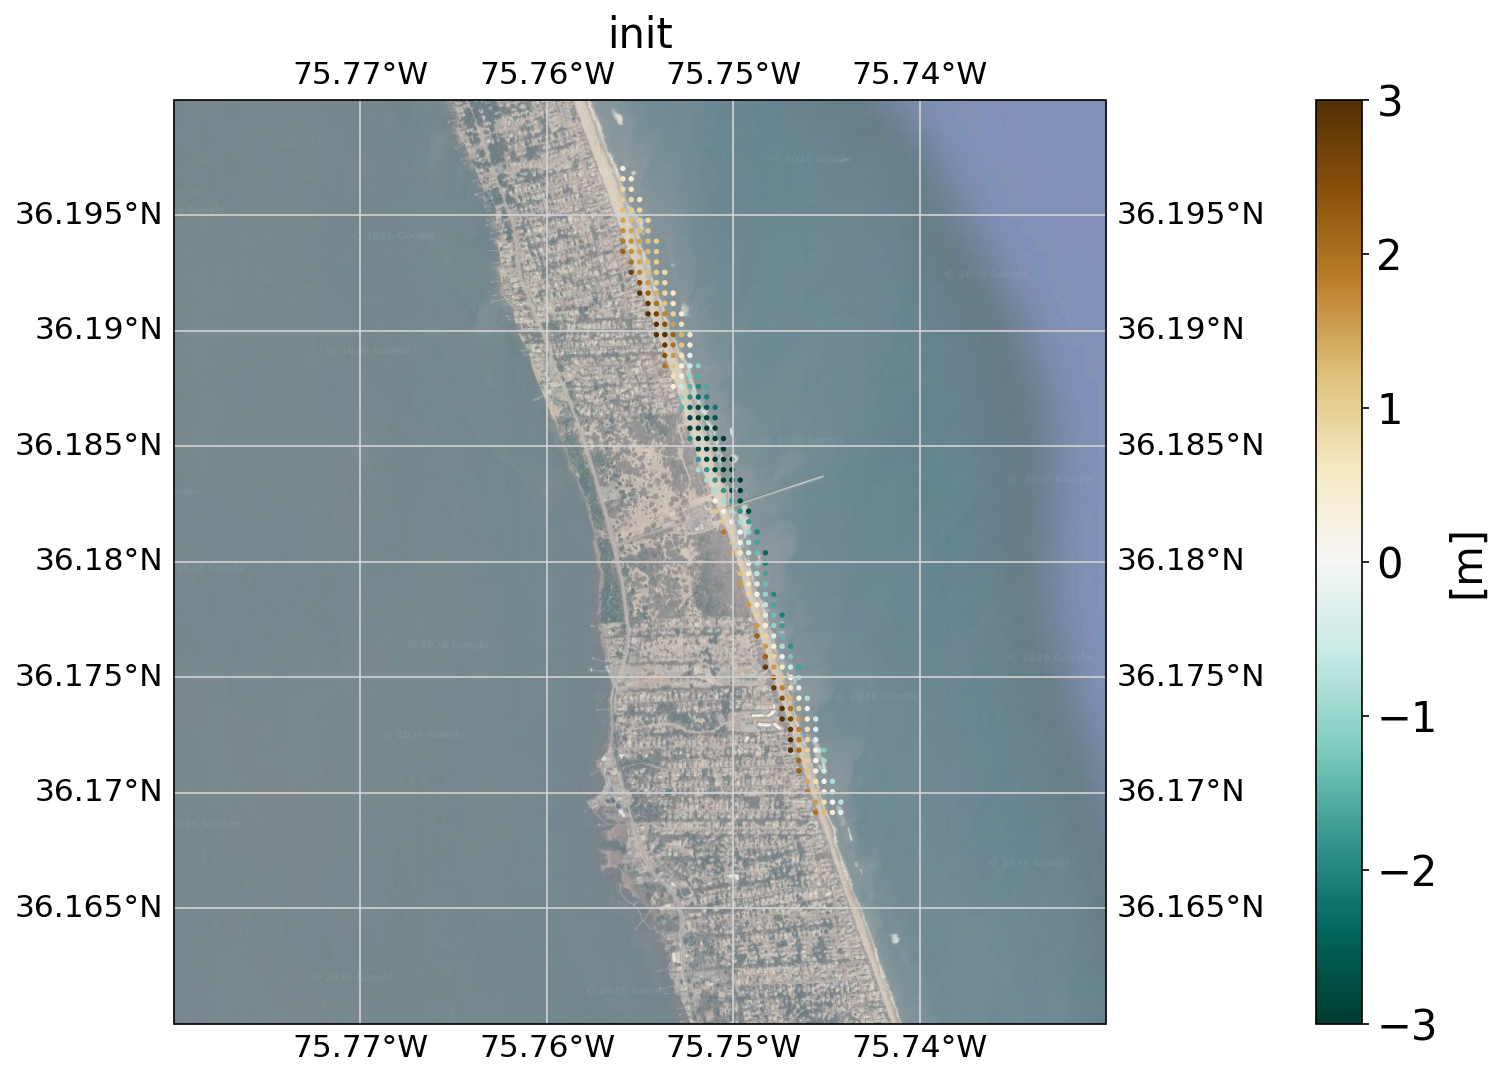

In [42]:
if animation:
    extent = [-75.78, -75.73, 36.16, 36.2]
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_poly.geometry.x
    y = x_state_poly.geometry.y
    anim = CD_visualisation.movie(x_state_poly, x, y,
            col_list_kf, first_col='init', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='Duck_KF.gif')

#### RTS

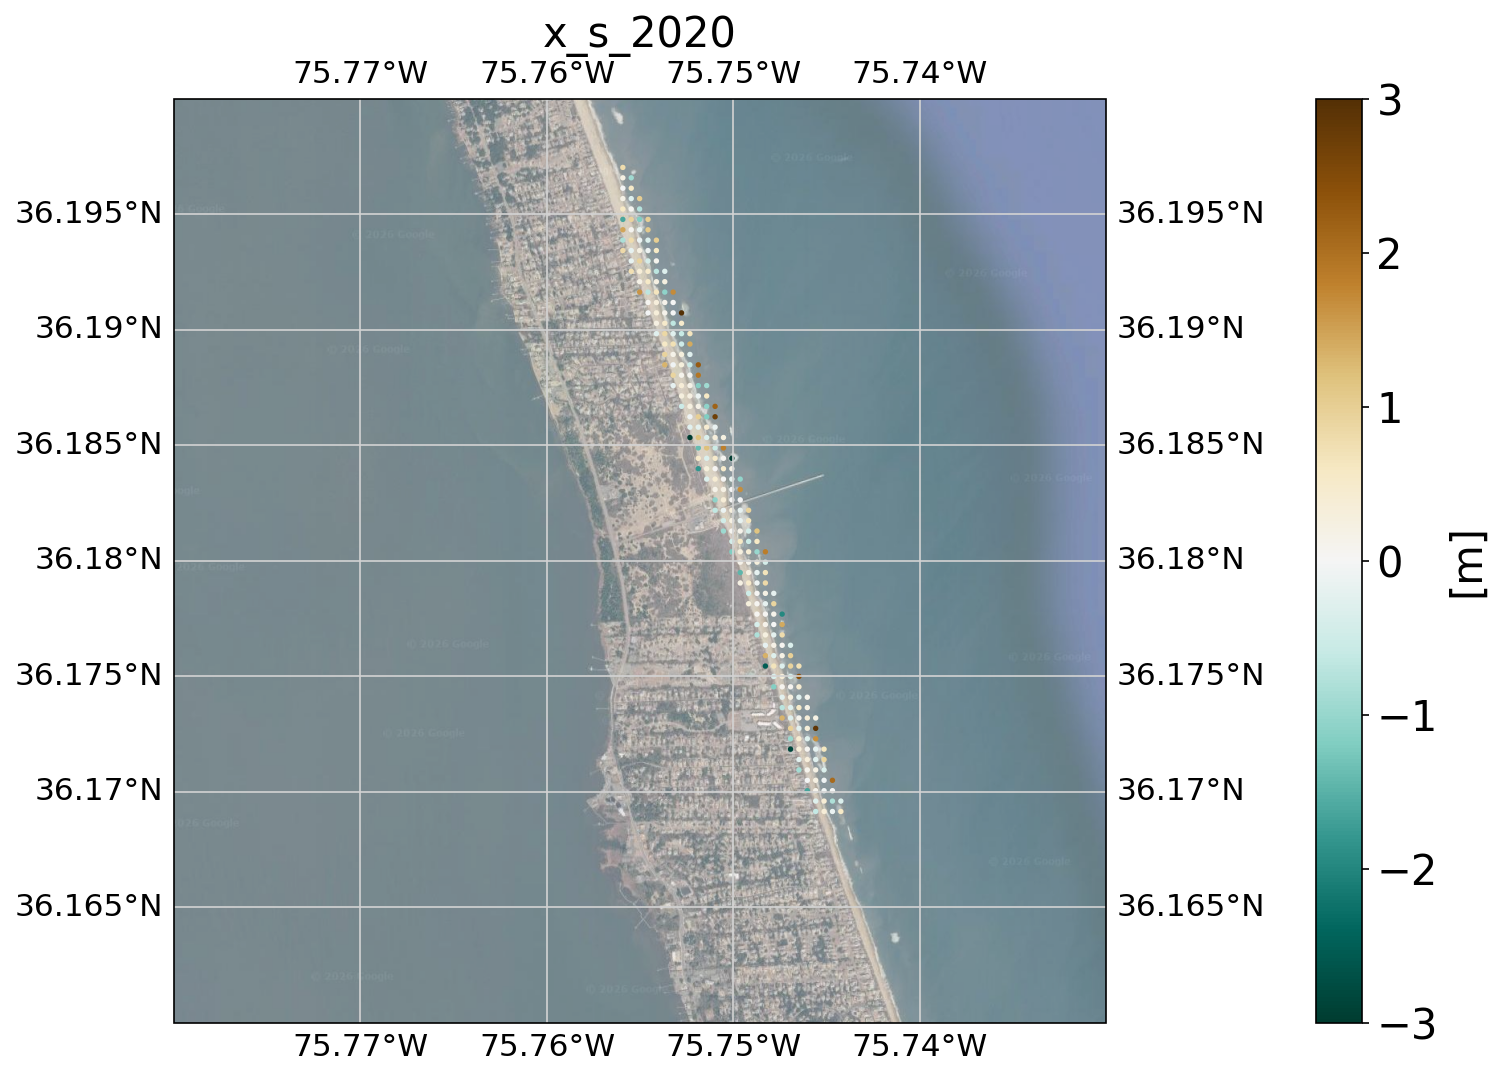

In [43]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_poly.geometry.x
    y = x_state_s_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='Duck_RTS.gif')

#### Single year result map

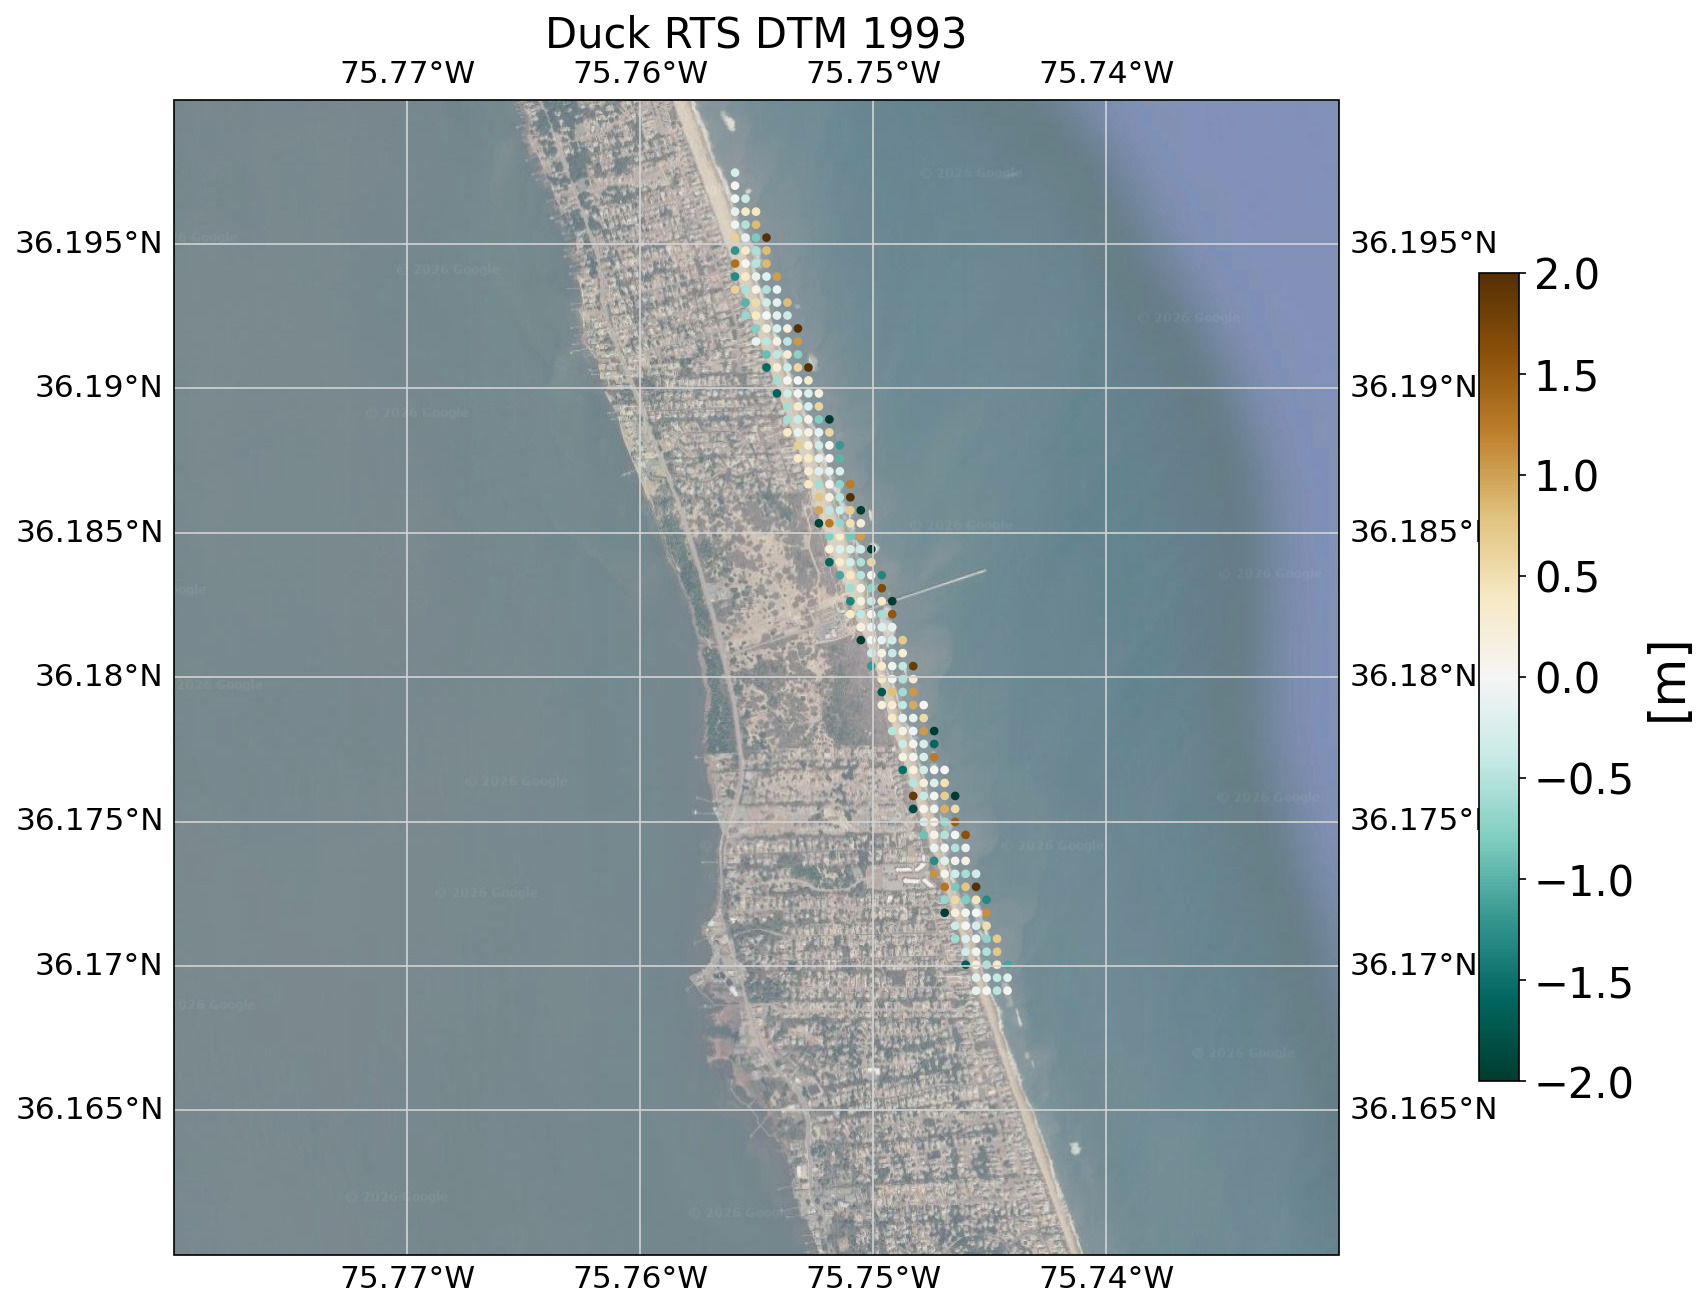

In [44]:
projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,10), subplot_kw=dict(projection=request.crs))
ax.set_extent(extent, crs=projection)
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')

zoom = 15
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = x_state.geometry.x
y = x_state.geometry.y

plot = ax.scatter(x, y, marker='o', s=10, c = x_state_s['x_s_1993'],
                  cmap='BrBG_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'Duck RTS DTM 1993')

plt.savefig(f'{path_output}Duck_RTS_DTM_1993.png', dpi=300, bbox_inches='tight')

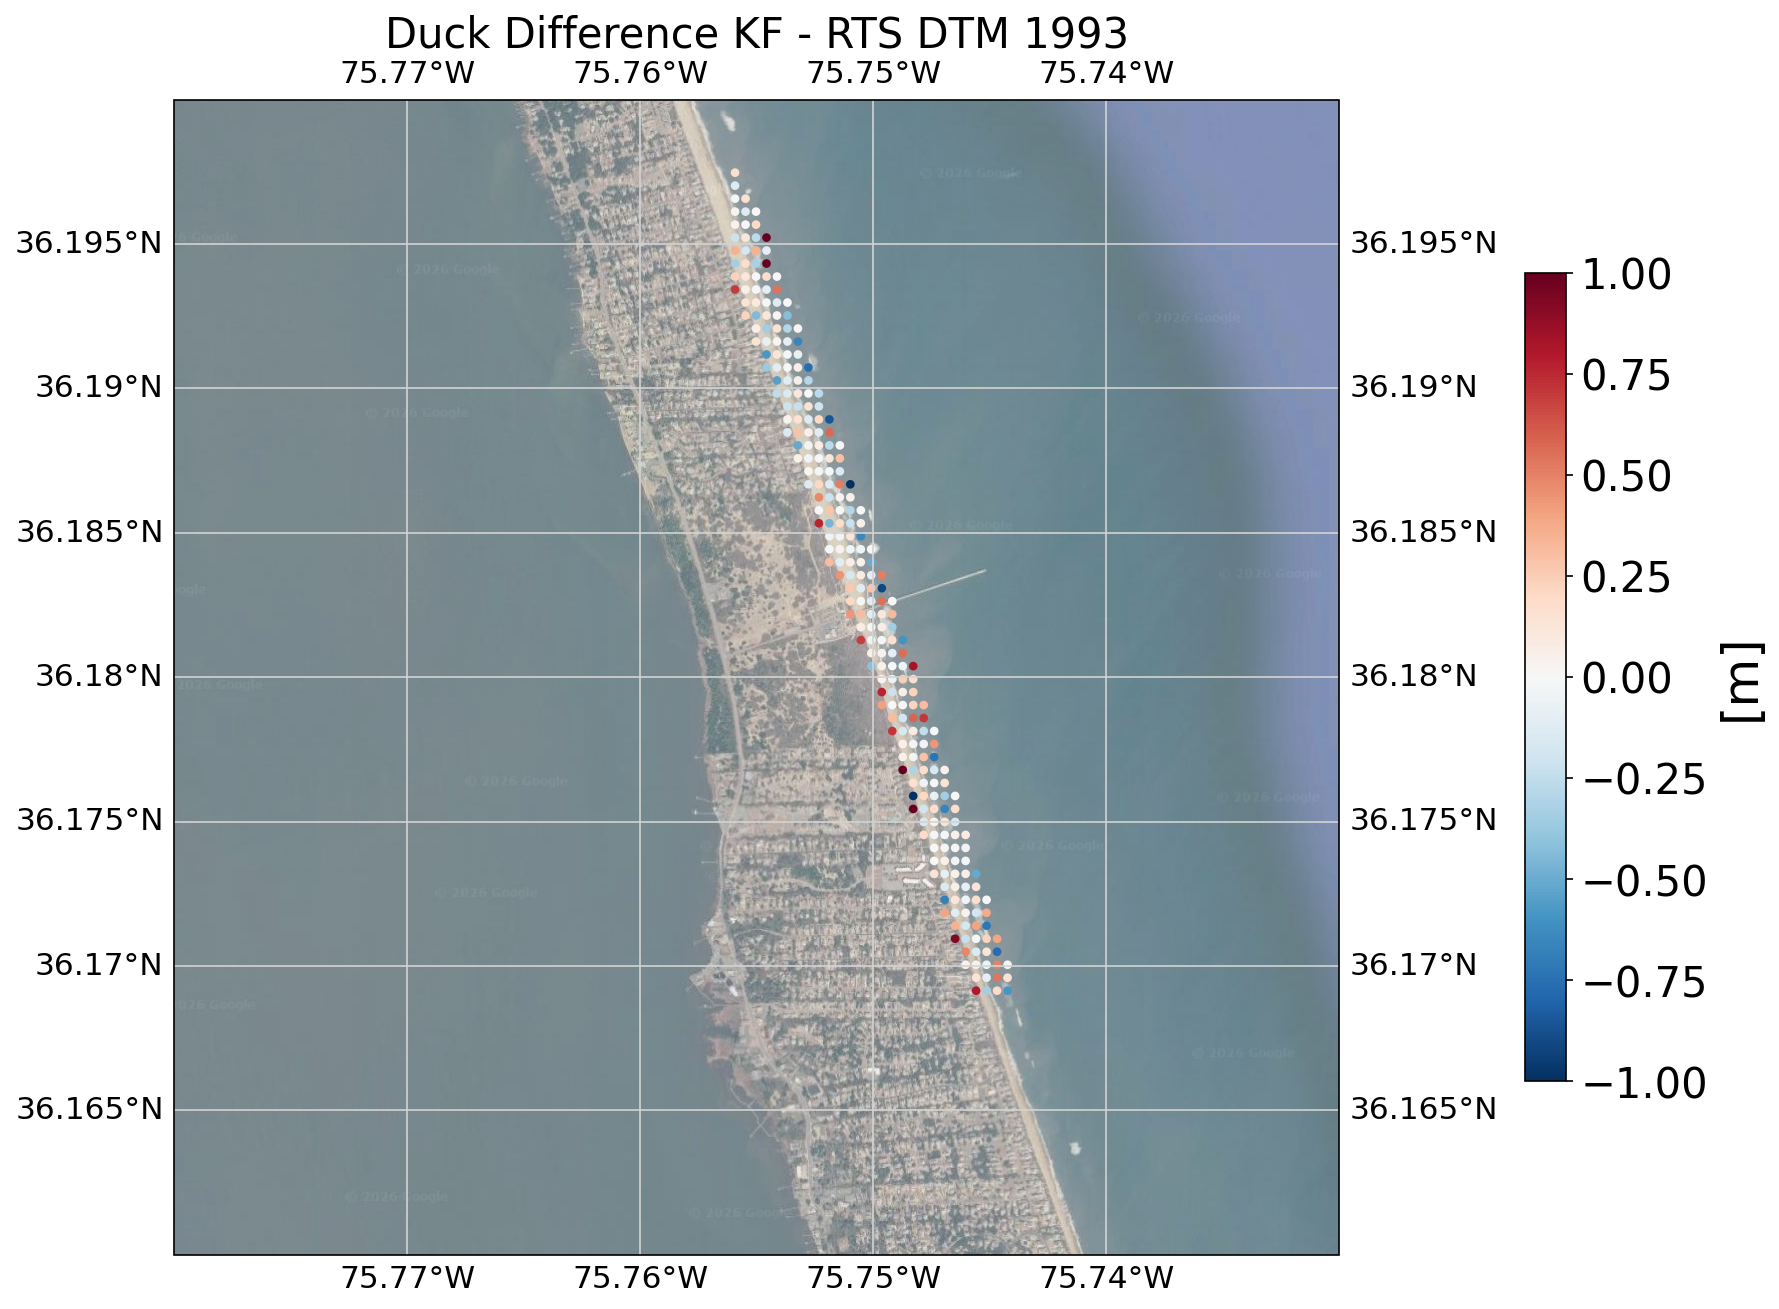

In [45]:
diff = x_state_s['x_s_1993'] - x_state['x_up_1993']

extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, marker='o', s=10, c=diff,
                  cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-1, vmax=1, )

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
ax.set_title('Duck Difference KF - RTS DTM 1993');

plt.savefig(f'{path_output}Duck_diff_kf-rts_1993.png', dpi=300, bbox_inches='tight')

### Map of variances

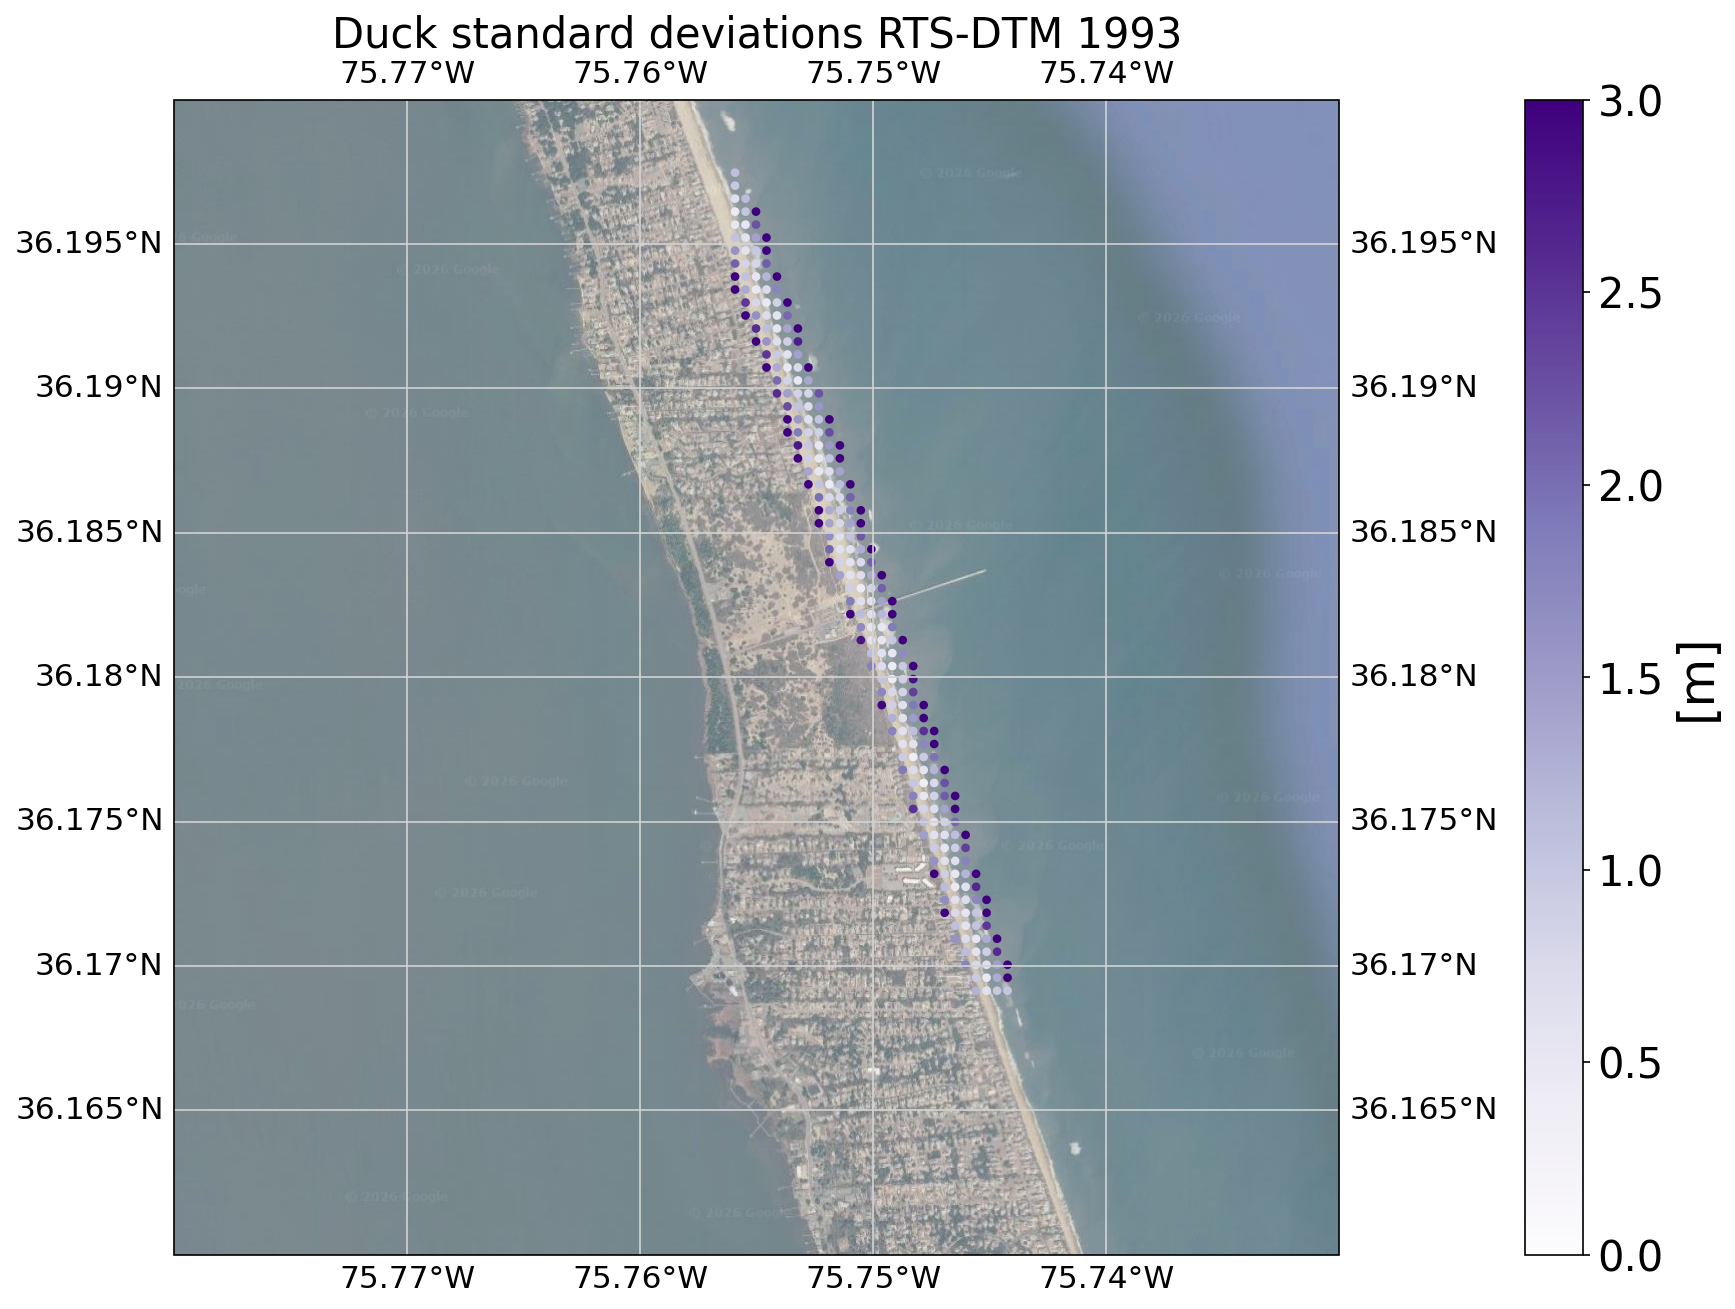

In [46]:
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15, background=True)
x = x_state.geometry.x
y = x_state.geometry.y
data = np.diagonal(sigma_xx_s['1993'].toarray())
data = np.sqrt(data)
plot = ax.scatter(x, y, marker='o', s=10, c = data,
                  cmap='Purples', transform=ccrs.PlateCarree(), vmin=0, vmax=3)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('Duck standard deviations RTS-DTM 1993')
plt.savefig(f'{path_output}Duck_std_1993.png', dpi=300, bbox_inches='tight')
# !!! some values at the seaward edge go up to 10